In [1]:
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np
from architecture.session_bigdata import Session, egeofno_ver1, egeofno_ver2, \
    egeofno_ver3, egeofno_ver4, svdfno_ver1, svdfno_ver2, svdfno_ver3, svdfno_ver4, fno_ver3


######### FIX MATRIX PLOTTING TAMALE #####
N_train = 40000
data_dir = "/home/emastr/deep-micro-slip-model/data/micro_geometries_boundcurv_repar_256_torch/data_2.torch"
save_dir = "/mnt/data0/emastr/article_training_hugedata/"
fig_dir = "/home/emastr/deep-micro-slip-model/data/"

device = "cuda:1"

option=2
if option == 1:
    name = "fno_ver1"
    label = "Geo FNO"
    net_gen = egeofno_ver1
else:
    name = "fno_vanilla_ver3"
    label = "Vanilla FNO"
    net_gen = fno_ver3
    
colors = ["steelblue", "indianred"]

def load_nets():
    nets = []
    #plt.figure(figsize=(8,8))
    for seed in [0, 1, 2, 3, 4, 5]:#, 4, 5]:
        #save_name = f"svdfno_ver{idx}_seed{seed}"
        save_name = f"{name}_seed{seed}"
        save = torch.load(f"{save_dir}{save_name}_{N_train}.Torch")
        state_dict = save["state dict"]
        net_settings = save["settings"]
        net = net_gen(device=device)
        net.load_state_dict(state_dict)
        nets.append(net)
    return nets, net_settings
    
nets, net_settings = load_nets()
net_settings["device"] = device
net_settings["num_pts"] = 256
net_settings["dtype"] = torch.float32

rel error: 0.06054846942424774
rel error: 0.04307876527309418
rel error: 0.0835595354437828


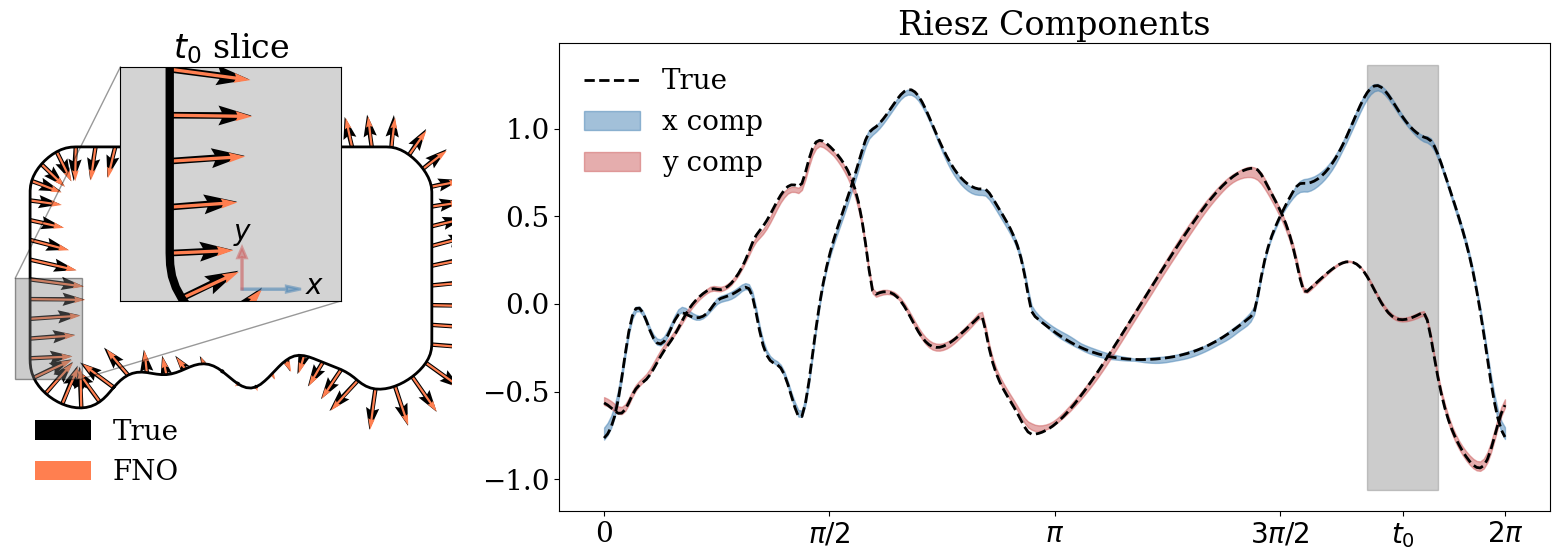

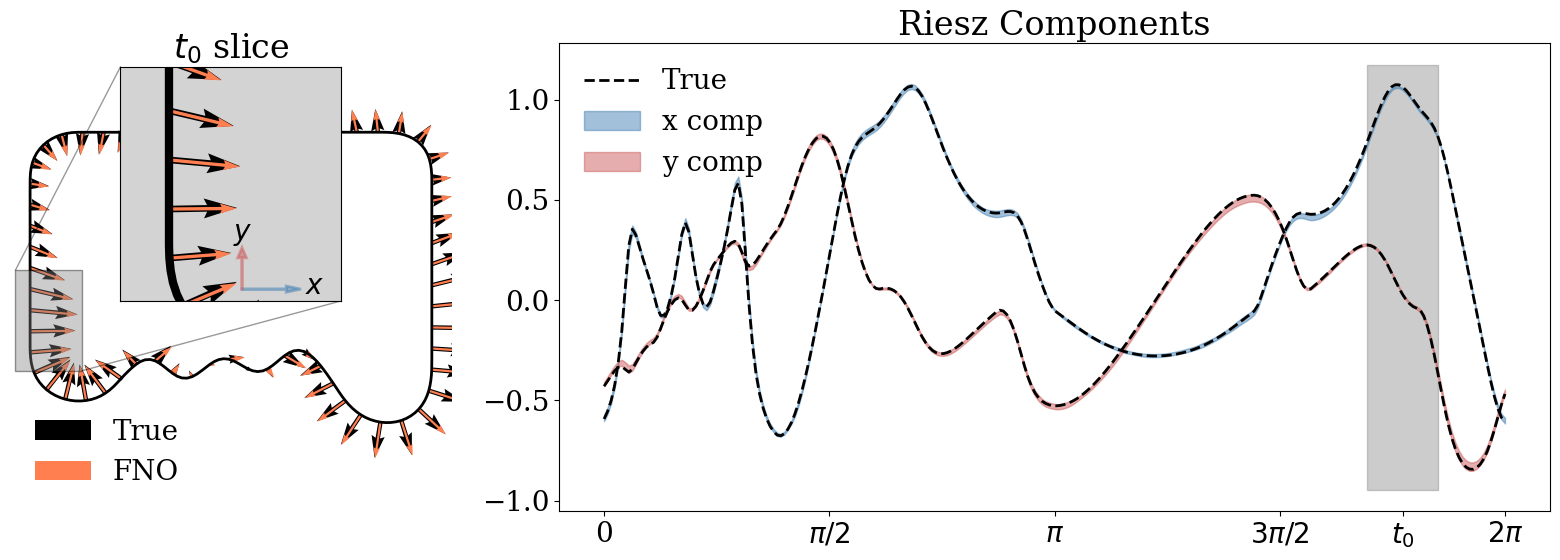

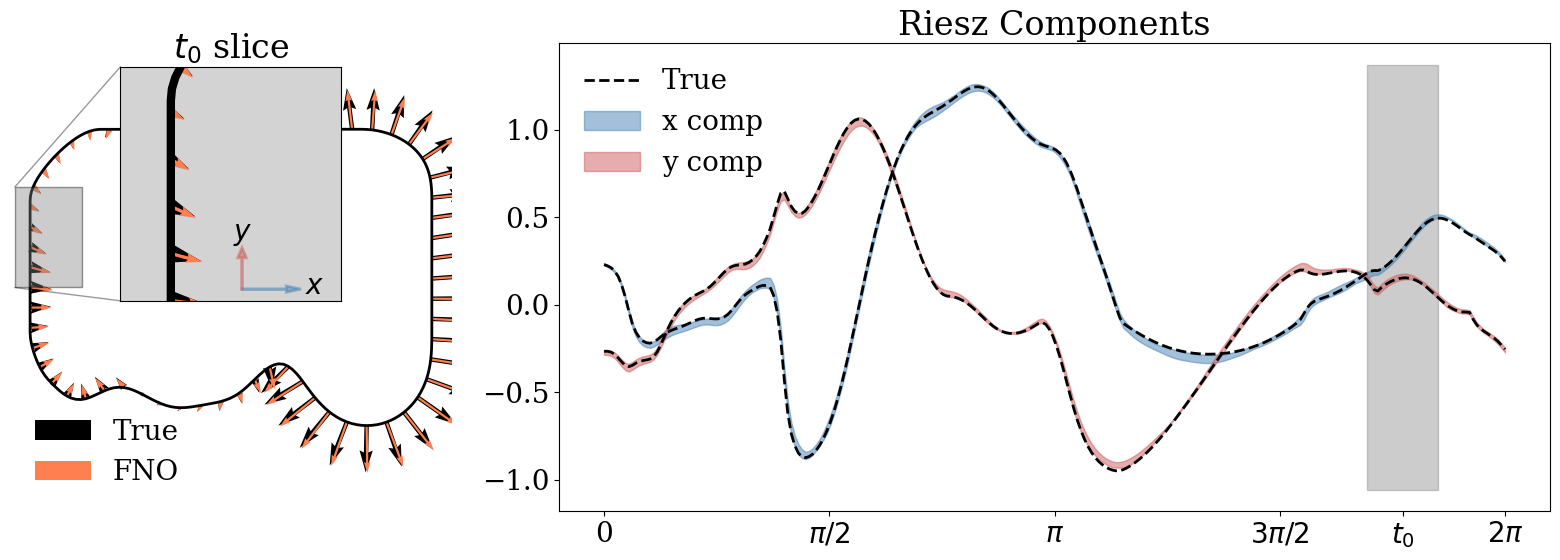

In [2]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8,8)
matplotlib.rcParams['font.size'] = 20
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['lines.linewidth'] = 2
data_idx = 42

def add_subplot_axes(ax,rect,axisbg='w'):
    fig = plt.gcf()
    box = ax.get_position()
    width = box.width
    height = box.height
    inax_position  = ax.transAxes.transform(rect[0:2])
    transFigure = fig.transFigure.inverted()
    infig_position = transFigure.transform(inax_position)    
    x = infig_position[0]
    y = infig_position[1]
    width *= rect[2]
    height *= rect[3]  # <= Typo was here
    #subax = fig.add_axes([x,y,width,height],facecolor=facecolor)  # matplotlib 2.0+
    subax = fig.add_axes([x,y,width,height])
    x_labelsize = subax.get_xticklabels()[0].get_size()
    y_labelsize = subax.get_yticklabels()[0].get_size()
    x_labelsize *= rect[2]**0.5
    y_labelsize *= rect[3]**0.5
    subax.xaxis.set_tick_params(labelsize=x_labelsize)
    subax.yaxis.set_tick_params(labelsize=y_labelsize)
    return subax


for data_idx in [40, 0, 42]:

    def plot(data, net):
            # Plot example
            (x, y) = data[data_idx]
            xc, yc = x[None, :, :], y[None, :, :]
            f = [net(xc).squeeze().detach().cpu() for net in nets]
            x = xc.squeeze().detach().cpu()
            y = yc.squeeze().detach().cpu()
            t = np.linspace(0, 2*np.pi, x.shape[-1])
            return f, x, y, t



        
    data = Session.get_data(nets[0], data_dir, device)
    xcord = data.inp['x'][data_idx].detach().cpu()
    ycord = data.inp['y'][data_idx].detach().cpu()

    f, x, y, t = plot(data, nets)

    ymean = np.max(np.abs(y.numpy()), axis=-1)

    print(f"rel error: {np.linalg.norm(y-f[0])/np.linalg.norm(y)}")

    ftot = np.array(f)
    fmax = np.max(ftot, axis=0)
    fmin = np.min(ftot, axis=0)


    fig = plt.figure(figsize=(16,6))
    ax = plt.subplot2grid((1, 3), (0, 1), colspan=2)
    plt.title("Riesz Components")
    labels = ["x comp", "y comp"]
    idx = [-3, -4]
    for i in range(2):
        s = 1#float(1/ymean[-i])
        
        plt.plot(t, y[idx[i]], 'k--', label="True" if i==0 else None)
        plt.fill_between(t, fmax[idx[i]], fmin[idx[i]], color=colors[i], label=labels[i], alpha=0.5)

    

    idx0 = -40
    idx1 = -20
    tidx0, xidx0, yidx0 = t[idx0], xcord[idx0], ycord[idx0]    
    tidx1, xidx1, yidx1 = t[idx1], xcord[idx1], ycord[idx1]
    plt.xticks([np.pi*k for k in [0, 0.5, 1, 1.5, 2]] + [(tidx1+tidx0)/2], ["0", "$\\pi/2$", "$\\pi$", "$3\\pi/2$", "$2\\pi$", "$t_0$"])
    plt.fill([tidx0, tidx1, tidx1, tidx0], [ax.get_ylim()[0], ax.get_ylim()[0], ax.get_ylim()[1], ax.get_ylim()[1]], color="gray", alpha=0.4, zorder=-10)
    
    plt.legend(frameon=False, loc="upper left")
    
    ax = plt.subplot2grid((1, 3), (0, 0), colspan=1)
    hlim = -1.
    skip = 4
    
    xcoord_sub = xcord[::skip]
    ycoord_sub = ycord[::skip]
    rxcoord_sub = y[idx[0],::skip]
    rycoord_sub = -y[idx[1],::skip]
    rnorm = np.sqrt(rxcoord_sub**2 + rycoord_sub**2)
    #rxcoord_sub = rxcoord_sub/rnorm
    #rycoord_sub = rycoord_sub/rnorm

    plt.plot(np.concatenate([xcord, xcord[0:1]]), np.concatenate([ycord, ycord[0:1]]), 'k', linewidth=2)
    plt.quiver(xcoord_sub, ycoord_sub, rxcoord_sub*(ycoord_sub > hlim), rycoord_sub*(ycoord_sub > hlim), color="k", label="True", scale=10, width=0.01)
    plt.quiver(xcoord_sub, ycoord_sub, fmax[idx[0]][::skip], -fmax[idx[1]][::skip], color="coral", label="FNO", scale=10, alpha=1, width=0.005)

    #xlim = ax.get_xlim()
    #xwid = xlim[1] - xlim[0]
    #ylim = ax.get_ylim()
   # ywid = ylim[1] - ylim[0]
    #lt.xlim(xlim[0]-xwid*0.2, xlim[1]+xwid*0.2)
    #plt.ylim(ylim[0]-ywid*0.2, ylim[1]+ywid*0.2)
    #scale=7
    #for x, y, rxmin, rymin, rxmax, rymax in zip(xcoord_sub, ycoord_sub, fmin[idx[0]][::skip], fmin[idx[1]][::skip], fmax[idx[0]][::skip], fmax[idx[1]][::skip]):
    #    x0 = (rxmax + rxmin)/2/scale
        #y0 = (rymax + rymin)/2/scale
        #plt.fill([x+rxmax/scale, x+x0, x+rxmin/scale, x+x0], [y+y0, y+rymax/scale, y+y0, y+rymin/scale], color="gray", alpha=0.5)



    plt.axis("equal")
    plt.axis("off")
    plt.legend(frameon=False, loc="lower left")
    
    
    #yheight = min(ycord) +  (max(ycord) - min(ycord))/3
    wid = (max(xcord) - min(xcord))/8
    xcenter = (xidx0 + xidx1)/2
    ycenter = (yidx0 + yidx1)/2
    xbox = (xcenter-wid/3, xcenter+wid)
    ybox = (ycenter-wid, ycenter+wid)
    #xbox = (min(xcord)-0.03*(max(xcord)-min(xcord)), min(xcord)+0.17*(max(xcord)-min(xcord)))
    #ybox = (min(ycord), min(ycord)+0.2*(max(xcord)-min(xcord)))
    #ybox = (yheight, yheight+0.2*(max(xcord)-min(xcord)))
    zoom_fac = 3
    axins = ax.inset_axes([0.25, 0.45, 0.5, 0.5], xlim=xbox, ylim=ybox, xticklabels=[], yticklabels=[])
    
    # Set grey as bg color
    axins.set_facecolor("lightgray")
    axins.plot(np.concatenate([xcord, xcord[0:1]]), np.concatenate([ycord, ycord[0:1]]), 'k', label="True", linewidth=2*zoom_fac)
    axins.quiver(xcoord_sub, ycoord_sub, rxcoord_sub*(ycoord_sub > hlim), rycoord_sub*(ycoord_sub > hlim), color="k", label="True", scale=10/zoom_fac, width=0.01*zoom_fac)
    axins.quiver(xcoord_sub, ycoord_sub, fmax[idx[0]][::skip], -fmax[idx[1]][::skip], color="coral", scale=10/zoom_fac, alpha=1, width=0.005*zoom_fac)

    xlim = axins.get_xlim()
    xwid = xlim[1] - xlim[0]
    ylim = axins.get_ylim()
    ywid = ylim[1] - ylim[0]
    axins.arrow(xlim[1]-xwid/2+0.05*xwid, ylim[0]+0.05*ywid, xwid/5, 0, linewidth=2, head_width=xwid/25, head_length=xwid/15, color=colors[0], alpha=0.5)
    axins.arrow(xlim[1]-xwid/2+0.05*xwid, ylim[0]+0.05*ywid, 0, xwid/5, linewidth=2, head_width=xwid/25, head_length=xwid/15, color=colors[1], alpha=0.5)
    axins.text(xlim[1]-xwid/2+0.01*xwid, ylim[0]+0.05*ywid+xwid/3.2, "$y$", fontsize=20)
    axins.text(xlim[1]-xwid/2+0.05*xwid+xwid/3.5, ylim[0]+0.03*ywid, "$x$", fontsize=20)
    #plot(axins, data_deep, data_classic)
    axins.set_xlabel("")
    axins.set_ylabel("")
    axins.set_xticks([])
    axins.set_yticks([])
    axins.set_title("$t_0$ slice")
    ax.indicate_inset_zoom(axins, edgecolor="black", facecolor="gray", alpha=0.4)

    plt.tight_layout()
    #plt.xlim(-1, 1.5)
    #plt.ylim(-0.6, 1.3)
    fig.savefig(f"{fig_dir}sample_{data_idx}.pdf", bbox_inches="tight")



